In [1]:
from kagglehub import dataset_download

dataset_dir = dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="dataset")

D:\ITI\Time Series\Labs\Lab3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_path = r"./dataset/BTCUSD_1m_Binance.csv"

In [6]:
import pandas as pd
df =pd.read_csv(data_path, usecols=['Close time', 'Close'])
df.head()

,Close,Close time
0,4261.48,2017-08-17 04:00:59.999
1,4261.48,2017-08-17 04:01:59.999
2,4280.56,2017-08-17 04:02:59.999
3,4261.48,2017-08-17 04:03:59.999
4,4261.48,2017-08-17 04:04:59.999


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4278671 entries, 0 to 4278670
Data columns (total 2 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Close       float64
 1   Close time  str    
dtypes: float64(1), str(1)
memory usage: 65.3 MB


In [8]:
df['Close time'] = pd.to_datetime(df['Close time'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4278671 entries, 0 to 4278670
Data columns (total 2 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Close       float64       
 1   Close time  datetime64[us]
dtypes: datetime64[us](1), float64(1)
memory usage: 65.3 MB


In [10]:
time_series = df.set_index('Close time')

In [12]:
time_series = time_series.resample('D').last()

In [13]:
time_series_df = pd.DataFrame({
    'ds':time_series.index,
    'y':time_series['Close']})
time_series_df

,ds,y
Close time,,
2017-08-17,2017-08-17,4285.08
2017-08-18,2017-08-18,4108.37
2017-08-19,2017-08-19,4139.98
2017-08-20,2017-08-20,4086.29
2017-08-21,2017-08-21,4016.00
...,...,...
2025-10-07,2025-10-07,121332.95
2025-10-08,2025-10-08,123306.00
2025-10-09,2025-10-09,121662.40


<Axes: xlabel='Close time'>

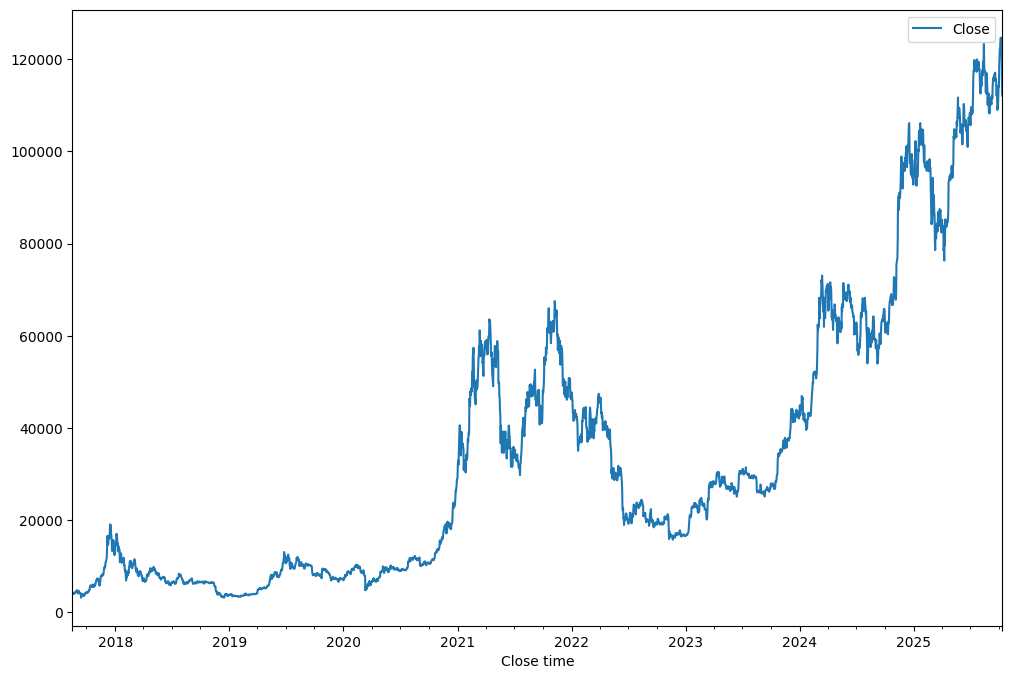

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
time_series.plot(ax=ax)

In [19]:
import numpy as np
time_series_df['y'] = np.log(time_series_df['y'])

<Axes: xlabel='ds'>

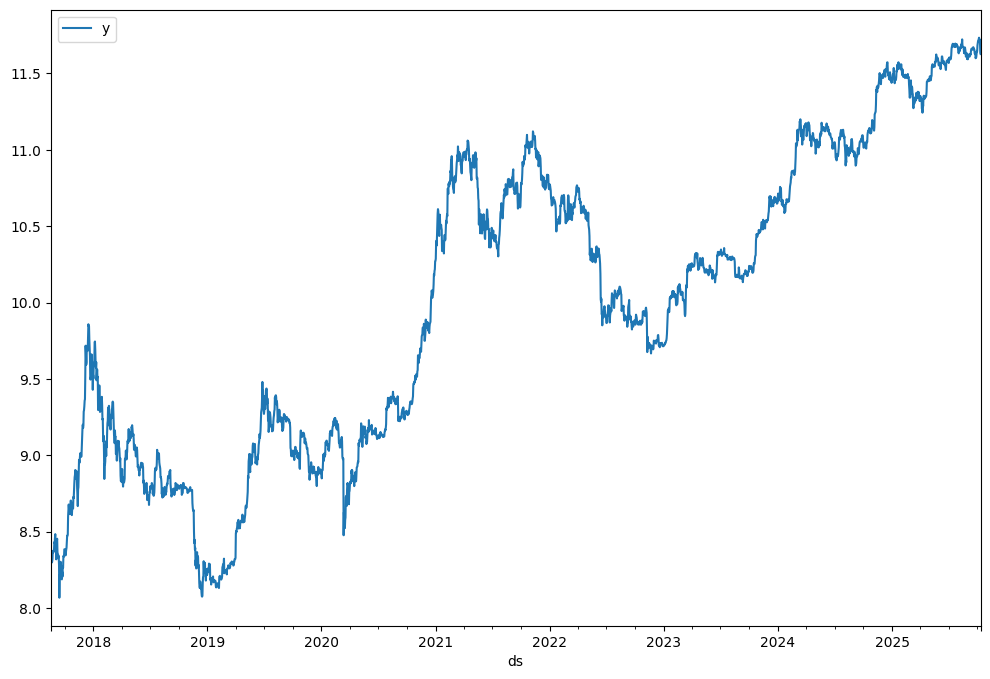

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
time_series_df.plot(x='ds', y='y', ax=ax)

In [24]:
! uv pip list --python .venv\Scripts\python.exe

Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
cmdstanpy                 1.3.0
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.61.1
fqdn                      1.5.1
h11                       0.16.0
holidays                  0.92
httpcore                  1.0.9
httpx              

In [25]:
from prophet import Prophet

In [31]:
baseline_model = Prophet()
baseline_model.add_seasonality(
    name="monthly_seasonality",
    period=30,
    fourier_order=10,
    mode='additive')

In [32]:
baseline_model.fit(time_series_df)

22:25:32 - cmdstanpy - INFO - Chain [1] start processing
22:25:33 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
time_series_df.tail()

,ds,y
Close time,,
2025-10-07,2025-10-07,11.706294
2025-10-08,2025-10-08,11.722424
2025-10-09,2025-10-09,11.709005
2025-10-10,2025-10-10,11.633146
2025-10-11,2025-10-11,11.626900


In [36]:
future_df = baseline_model.make_future_dataframe(periods=365, freq='D')

In [39]:
forecast = baseline_model.predict(future_df)
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'monthly_seasonality', 'monthly_seasonality_lower',
       'monthly_seasonality_upper', 'weekly', 'weekly_lower', 'weekly_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')

In [40]:
forecast[[
  "ds", "yhat", "yhat_lower", "yhat_upper"  
]]

,ds,yhat,yhat_lower,yhat_upper
0,2017-08-17,8.123580,7.979535,8.299409
1,2017-08-18,8.135970,7.984516,8.290222
2,2017-08-19,8.145669,7.978127,8.310913
3,2017-08-20,8.156502,7.988627,8.322986
4,2017-08-21,8.172143,8.017728,8.328028
...,...,...,...,...
3338,2026-10-07,12.154170,9.569970,14.818605
3339,2026-10-08,12.151743,9.552185,14.866887
3340,2026-10-09,12.163435,9.539289,14.891377
3341,2026-10-10,12.171854,9.575875,14.903359


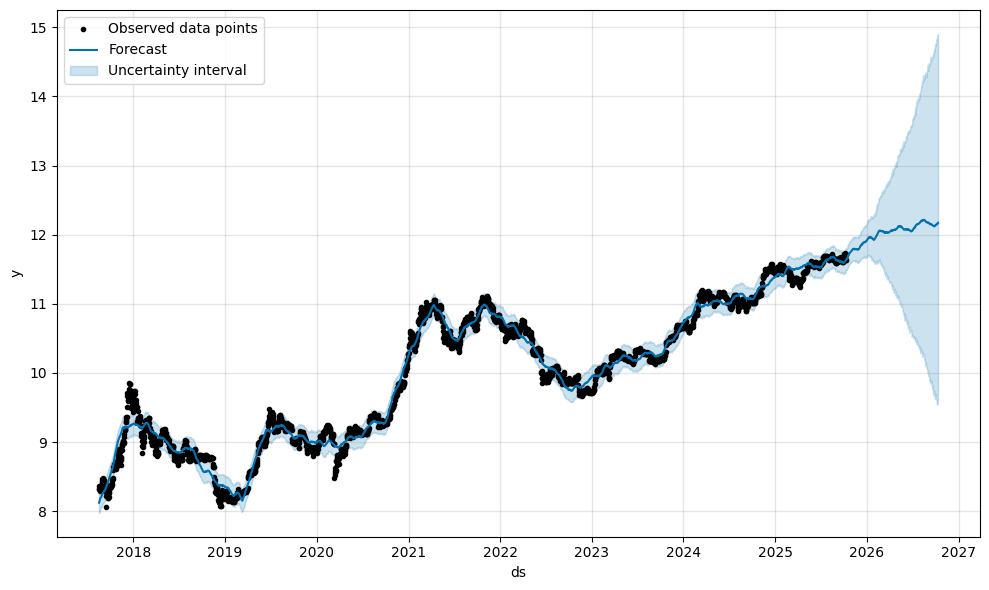

In [42]:
from prophet.plot import plot, plot_components

fig = plot(baseline_model, forecast, include_legend=True)

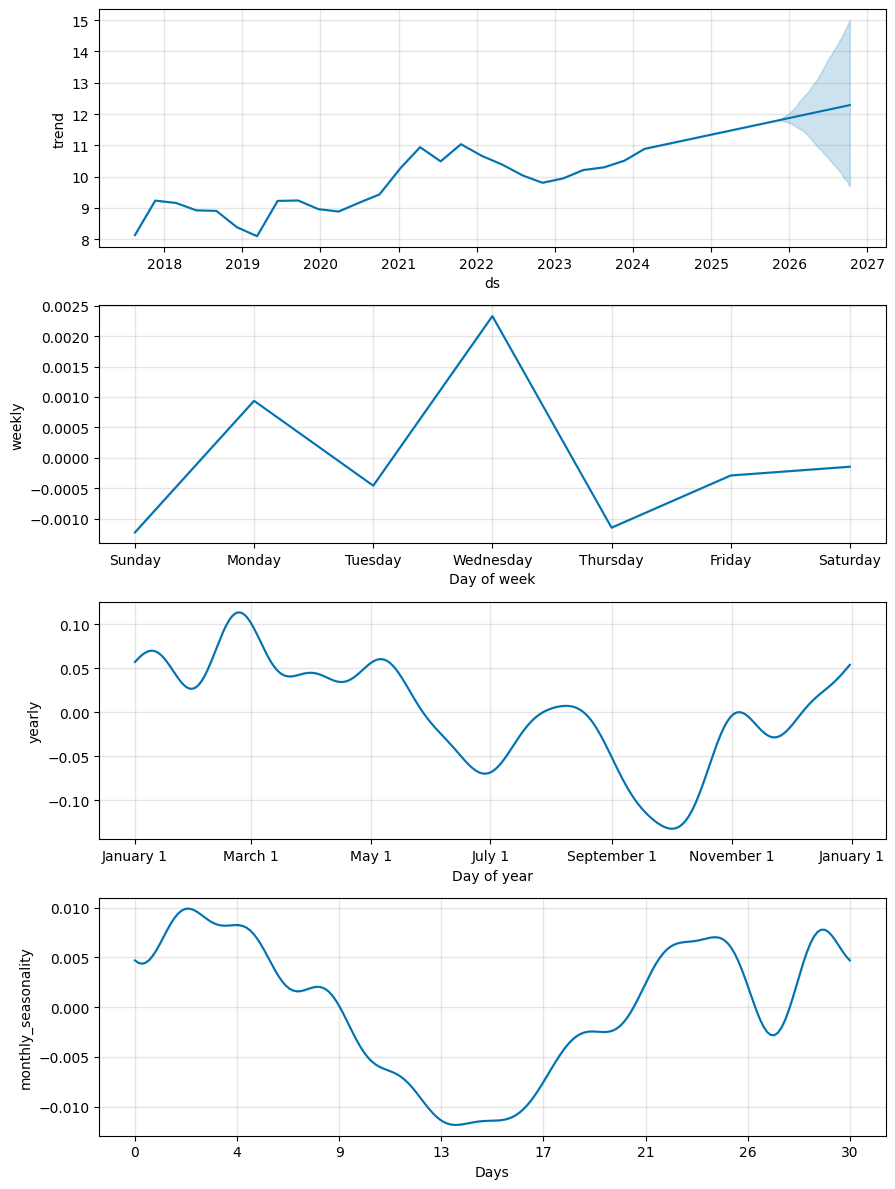

In [43]:
fig = plot_components(baseline_model, forecast)

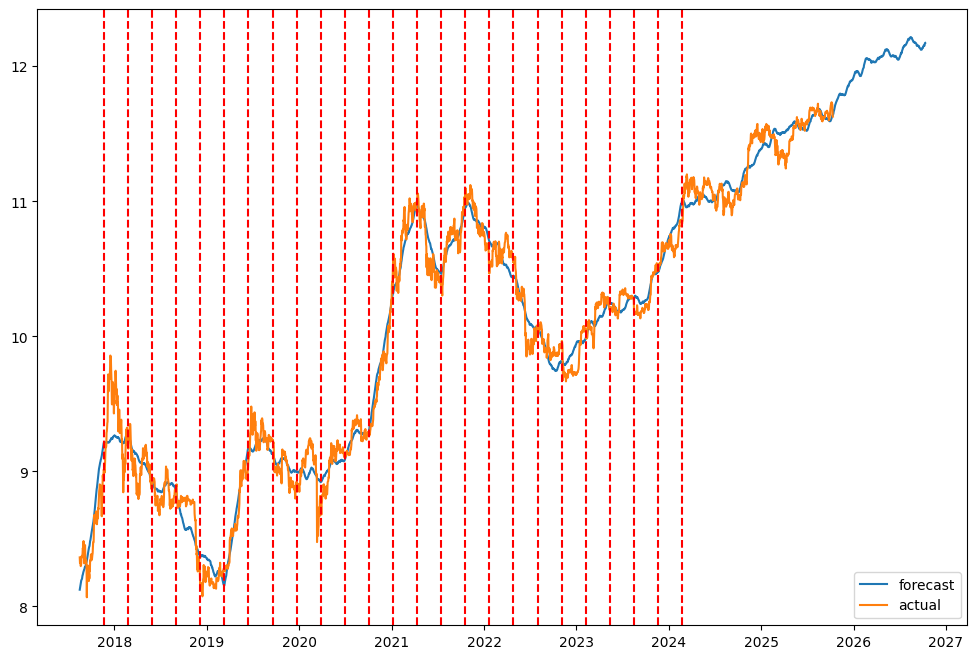

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.plot(forecast['ds'], forecast['yhat'], label='forecast')
ax.plot(time_series_df['ds'], time_series_df['y'], label='actual')
for cp in baseline_model.changepoints:
    ax.axvline(x=cp, linestyle='--', color='red')
ax.legend()

23:28:26 - cmdstanpy - INFO - Chain [1] start processing
23:28:26 - cmdstanpy - INFO - Chain [1] done processing
23:28:27 - cmdstanpy - INFO - Chain [1] start processing
23:28:27 - cmdstanpy - INFO - Chain [1] done processing
23:28:28 - cmdstanpy - INFO - Chain [1] start processing
23:28:29 - cmdstanpy - INFO - Chain [1] done processing
23:28:29 - cmdstanpy - INFO - Chain [1] start processing
23:28:30 - cmdstanpy - INFO - Chain [1] done processing
23:28:31 - cmdstanpy - INFO - Chain [1] start processing
23:28:32 - cmdstanpy - INFO - Chain [1] done processing
23:28:32 - cmdstanpy - INFO - Chain [1] start processing
23:28:33 - cmdstanpy - INFO - Chain [1] done processing


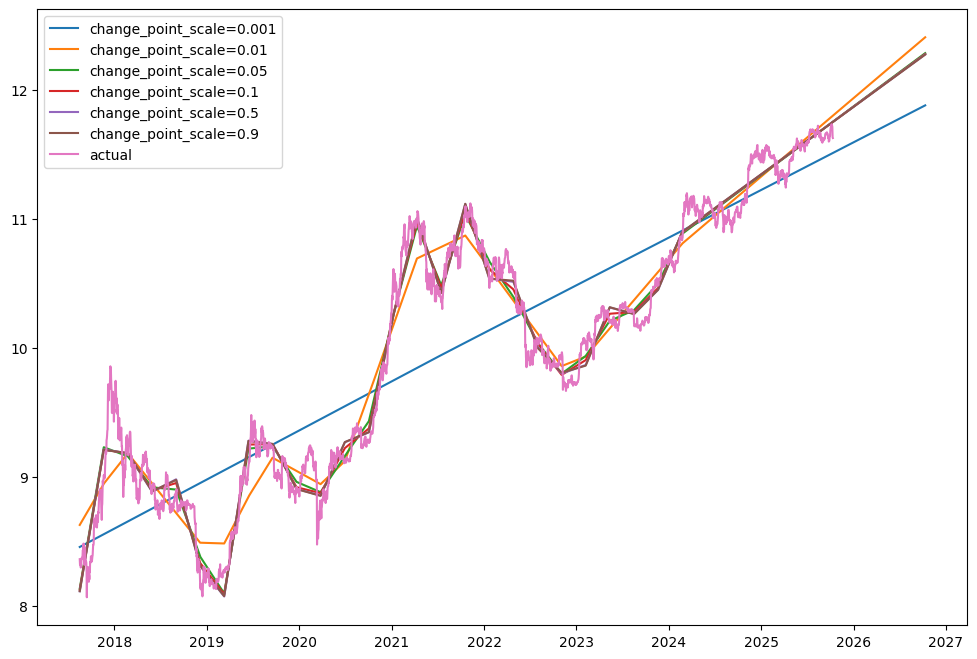

In [65]:
change_point_scales = [0.001, 0.01, 0.05, 0.1, 0.5, 0.9]
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for change_point_scale in change_point_scales:
    model = Prophet(changepoint_prior_scale=change_point_scale)
    model.fit(time_series_df)
    future_test  = model.make_future_dataframe(periods=365, freq='D')
    forecast_test = model.predict(future_test)
    ax.plot(forecast_test['ds'], forecast_test['trend'],label=f'change_point_scale={change_point_scale}')
    # for cp in model.changepoints:
    #     ax.axvline(x=cp, linestyle='--', color='black')
    # break
ax.plot(time_series_df['ds'], time_series_df['y'], label='actual')
ax.legend()

In [99]:
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(
    baseline_model,
    initial="30 days",
    horizon="3 days",
    period=" 30 days",
    parallel="processes"
)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


In [100]:
time_series_df['ds']

Close time
2017-08-17   2017-08-17
2017-08-18   2017-08-18
2017-08-19   2017-08-19
2017-08-20   2017-08-20
2017-08-21   2017-08-21
                ...    
2025-10-07   2025-10-07
2025-10-08   2025-10-08
2025-10-09   2025-10-09
2025-10-10   2025-10-10
2025-10-11   2025-10-11
Freq: D, Name: ds, Length: 2978, dtype: datetime64[us]

In [105]:
pd.to_datetime("2017-08-17") + pd.Timedelta(days=3)

Timestamp('2017-08-20 00:00:00')

In [102]:
df_cv.head(60)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2017-09-21,8.649210,8.632066,8.667496,8.191460,2017-09-20
1,2017-09-22,7.633389,7.614706,7.650923,8.187541,2017-09-20
2,2017-09-23,3.361131,3.342623,3.379695,8.237479,2017-09-20
3,2017-10-21,8.781222,8.744276,8.814715,8.703668,2017-10-20
4,2017-10-22,9.047118,9.011058,9.085266,8.691150,2017-10-20
5,2017-10-23,9.573046,9.540492,9.610505,8.685404,2017-10-20
6,2017-11-20,8.995514,8.942132,9.048030,9.013352,2017-11-19
7,2017-11-21,8.910140,8.858851,8.960052,9.002025,2017-11-19
8,2017-11-22,8.721758,8.669187,8.771971,9.012611,2017-11-19
9,2017-12-20,9.767449,9.702391,9.831151,9.710448,2017-12-19


In [112]:
h1, h2, h3 = [], [], []

In [116]:
for _, g in df_cv.groupby('cutoff'):
    x, y, z = np.abs(g['y'] - g['yhat']).tolist()
    h1.append(x)
    h2.append(y)
    h3.append(z)

np.mean(h3)

np.float64(0.18184182586982406)

In [103]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,0.020420,0.142899,0.109511,0.010964,0.008549,0.010960,0.646465
1,2 days,0.027268,0.165130,0.123517,0.012512,0.009055,0.012545,0.575758
2,3 days,0.274619,0.524041,0.181842,0.019411,0.009801,0.021899,0.555556


In [124]:
second_model = Prophet(seasonality_mode="multiplicative")
second_model.fit(time_series_df)

00:15:03 - cmdstanpy - INFO - Chain [1] start processing
00:15:04 - cmdstanpy - INFO - Chain [1] done processing


In [125]:
df_cv2 = cross_validation(
    second_model,
    initial="30 days",
    horizon="3 days",
    period=" 30 days",
    parallel="processes"
)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


In [126]:
performance_metrics(df_cv2)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,0.018030,0.134277,0.106183,0.010532,0.008610,0.010555,0.646465
1,2 days,0.023848,0.154427,0.118219,0.011853,0.009351,0.011894,0.626263
2,3 days,0.036127,0.190071,0.134027,0.013603,0.009849,0.013707,0.575758


In [128]:
future2_df = second_model.make_future_dataframe(periods=365, freq='D')
forecast2 = second_model.predict(future2_df)

In [118]:
from prophet.serialize import model_to_json, model_from_json
import json

with open('modek.json', 'w') as f:
    json.dump(model_to_json(baseline_model), f)

In [120]:
with open('modek.json', 'r') as f:
    model_loaded = model_from_json(json.load(f))

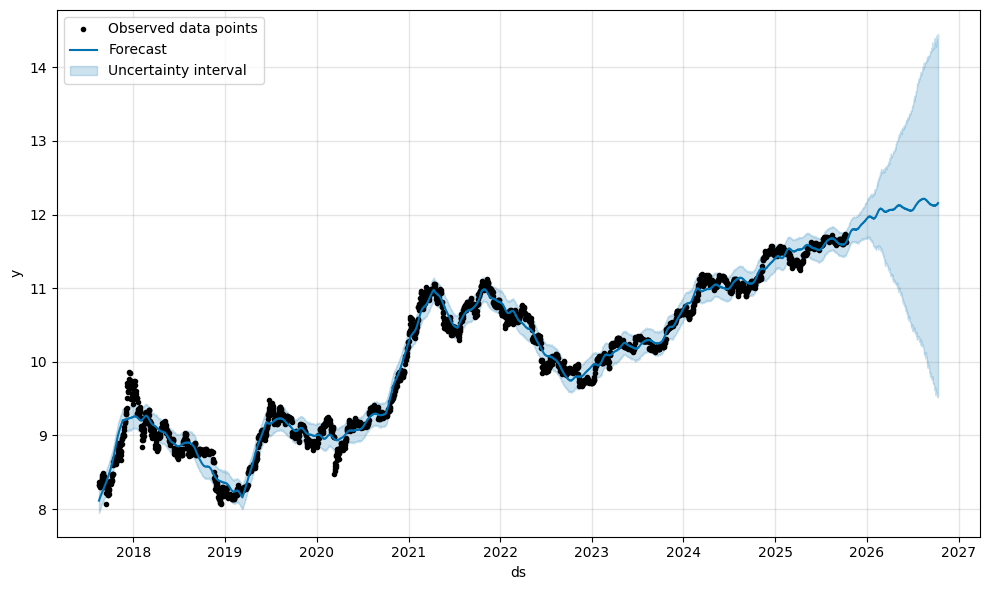

In [129]:
plot(second_model, forecast2, include_legend=True);